# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Pranaja Adyatma Budiman| 5054251009|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)

# --- Data handling & EDA ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Modelling ---
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# --- Evaluasi ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)


In [ ]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.

df = pd.read_csv('diabetes.csv')  # Ganti 'data.csv' dengan path dataset Anda
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
# Pisahkan fitur (X) dan target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split 80:20 dengan stratify agar proporsi kelas 0/1 tetap seimbang
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\nDistribusi y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribusi y_test:")
print(y_test.value_counts(normalize=True))

X_train: (614, 8)
X_test : (154, 8)

Distribusi y_train:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Distribusi y_test:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


Outcome
0    500
1    268
Name: count, dtype: int64

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


C:\Users\pranaja\AppData\Local\Temp\ipykernel_8608\436292113.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='pastel')


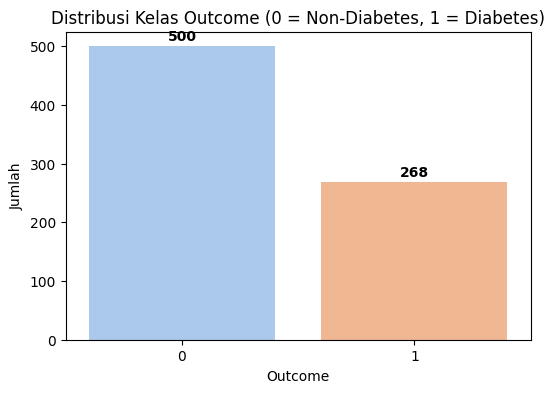

In [5]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

# Lihat jumlah & proporsi tiap kelas
print(df['Outcome'].value_counts())
print()
print(df['Outcome'].value_counts(normalize=True))

# Bar plot distribusi kelas
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='pastel')
plt.title('Distribusi Kelas Outcome (0 = Non-Diabetes, 1 = Diabetes)')
plt.xlabel('Outcome')
plt.ylabel('Jumlah')
for i, v in enumerate(df['Outcome'].value_counts().sort_index()):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.show()

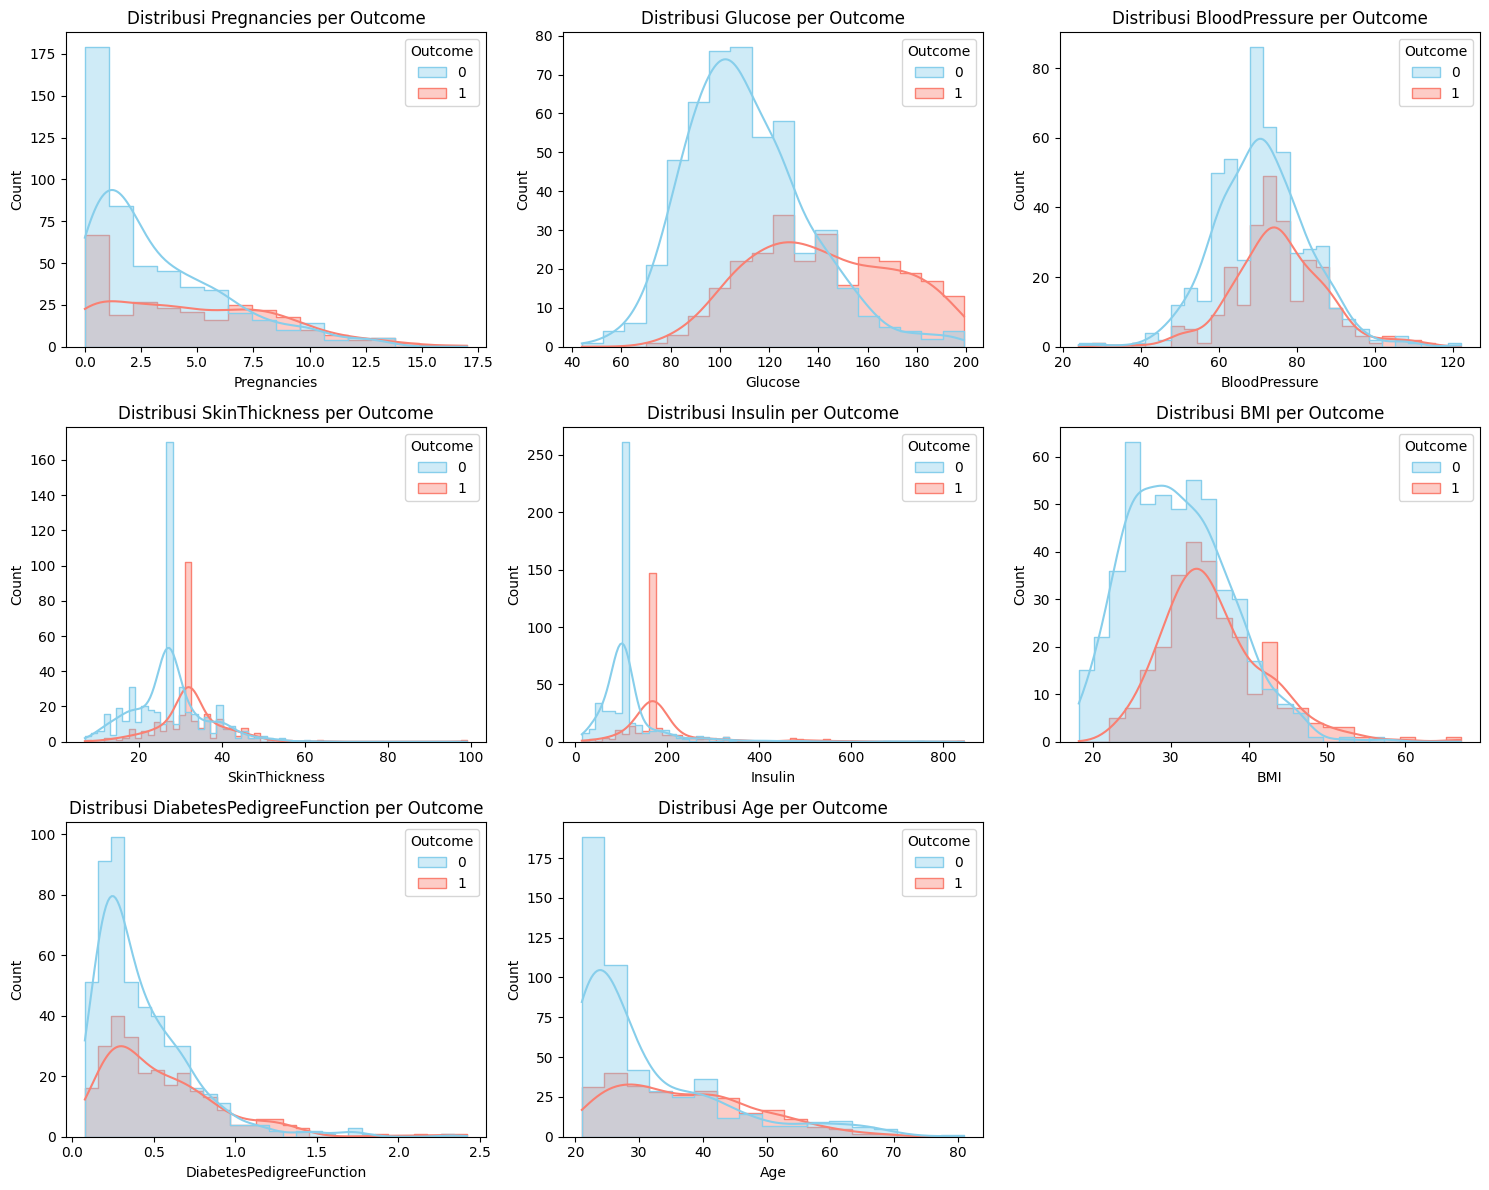

In [7]:
features = df.drop(columns=['Outcome']).columns

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(data=df, x=col, hue='Outcome', kde=True,
                 palette={0: 'skyblue', 1: 'salmon'},
                 element='step', alpha=0.4, ax=axes[i])
    axes[i].set_title(f'Distribusi {col} per Outcome')

# Hapus subplot kosong sisa (9 - 8 = 1)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

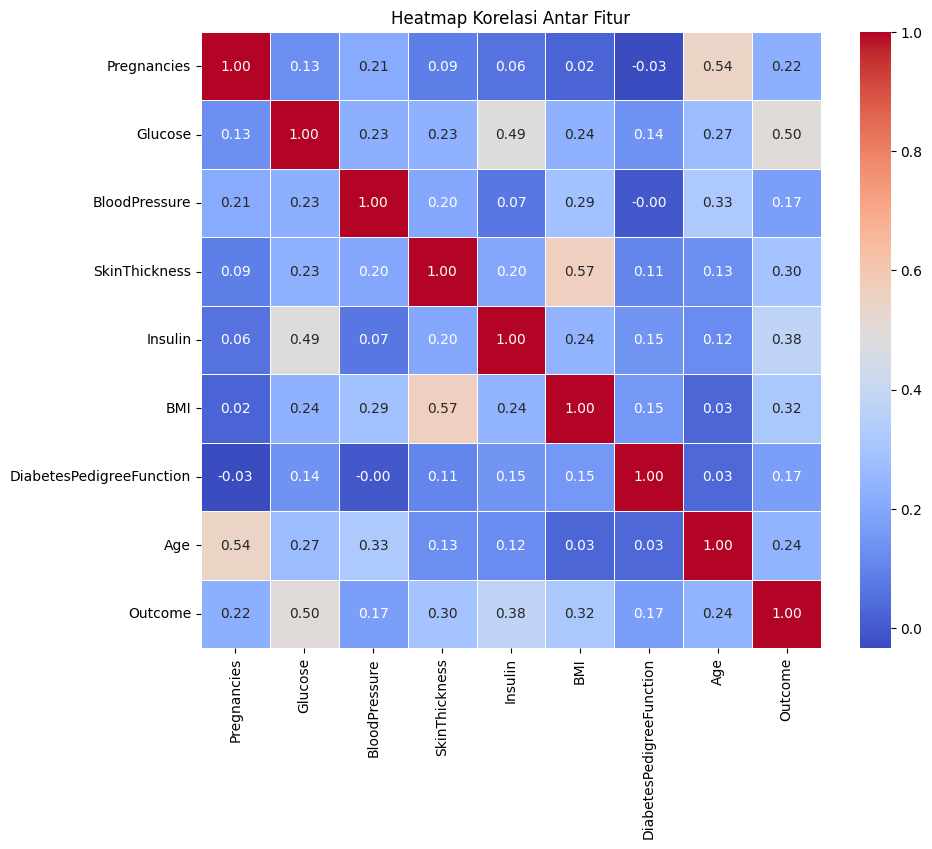

In [8]:
# Tampilkan heatmap korelasi antar fitur.

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [9]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.

cols_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Hitung jumlah nilai 0 per kolom
zero_counts = (df[cols_zero] == 0).sum().sort_values(ascending=False)
zero_percent = (df[cols_zero] == 0).mean().mul(100).round(2)

summary_zero = pd.DataFrame({
    'Jumlah_Nol': zero_counts,
    'Persen_Nol (%)': zero_percent
})
print(summary_zero)

               Jumlah_Nol  Persen_Nol (%)
Glucose                 0             0.0
BloodPressure           0             0.0
SkinThickness           0             0.0
Insulin                 0             0.0
BMI                     0             0.0


In [ ]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

In [ ]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

In [10]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.

# Inisialisasi scaler
scaler = StandardScaler()

# Fit HANYA di train, lalu transform keduanya (hindari leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Opsional: kembalikan ke DataFrame biar nama kolom tetap
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(X_train_scaled.mean().round(2).head())
print(X_train_scaled.std().round(2).head())

Pregnancies     -0.0
Glucose         -0.0
BloodPressure    0.0
SkinThickness   -0.0
Insulin          0.0
dtype: float64
Pregnancies      1.0
Glucose          1.0
BloodPressure    1.0
SkinThickness    1.0
Insulin          1.0
dtype: float64


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [11]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

print("Model GaussianNB berhasil dilatih.")

Model GaussianNB berhasil dilatih.


In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

# Prediksi label dan probabilitas kelas 1 (untuk ROC-AUC)
y_pred_nb = nb_model.predict(X_test_scaled)
y_proba_nb = nb_model.predict_proba(X_test_scaled)[:, 1]

print(y_pred_nb[:10])
print(y_proba_nb[:10])

[0 0 0 0 0 0 1 1 0 1]
[0.39463909 0.21090162 0.23283517 0.18530596 0.00605332 0.02725761
 0.85576897 0.99748446 0.00622202 0.994586  ]


## 3.2 Logistic Regression

In [13]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.

# Inisialisasi dan latih Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

print("Model Logistic Regression berhasil dilatih.")

Model Logistic Regression berhasil dilatih.


In [14]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

# Prediksi label dan probabilitas kelas 1 (untuk ROC-AUC)
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print(y_pred_lr[:10])
print(y_proba_lr[:10])

[0 0 0 0 0 0 1 1 0 1]
[0.47739551 0.07407477 0.37011559 0.33773074 0.03196289 0.10346784
 0.55984821 0.90195873 0.0672363  0.9042001 ]


# 4. Evaluasi Model

In [15]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.

# Hitung metrik untuk kedua model
results = pd.DataFrame({
    'Naive Bayes': [
        accuracy_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_nb)
    ],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr)
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])

print(results.round(4))

print("\n--- NB Report ---")
print(classification_report(y_test, y_pred_nb))
print("\n--- LR Report ---")
print(classification_report(y_test, y_pred_lr))

           Naive Bayes  Logistic Regression
Accuracy        0.7273               0.7078
Precision       0.6034               0.5882
Recall          0.6481               0.5556
F1-Score        0.6250               0.5714

--- NB Report ---
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       100
           1       0.60      0.65      0.62        54

    accuracy                           0.73       154
   macro avg       0.70      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154


--- LR Report ---
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       100
           1       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



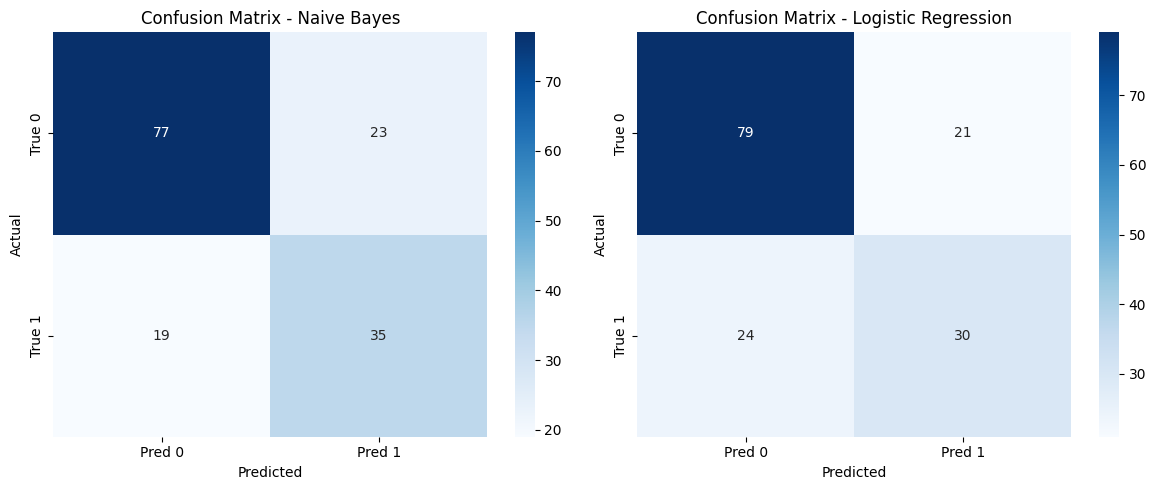

In [16]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes,
    [y_pred_nb, y_pred_lr],
    ['Confusion Matrix - Naive Bayes', 'Confusion Matrix - Logistic Regression']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

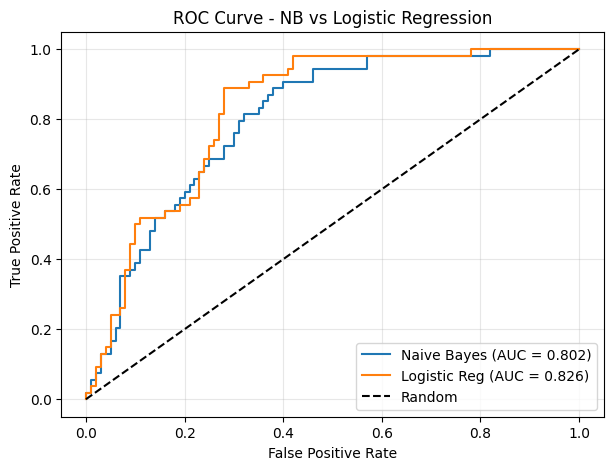

In [17]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.

# Hitung ROC & AUC kedua model
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_nb = auc(fpr_nb, tpr_nb)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(7, 5))
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.3f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Reg (AUC = {auc_lr:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - NB vs Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

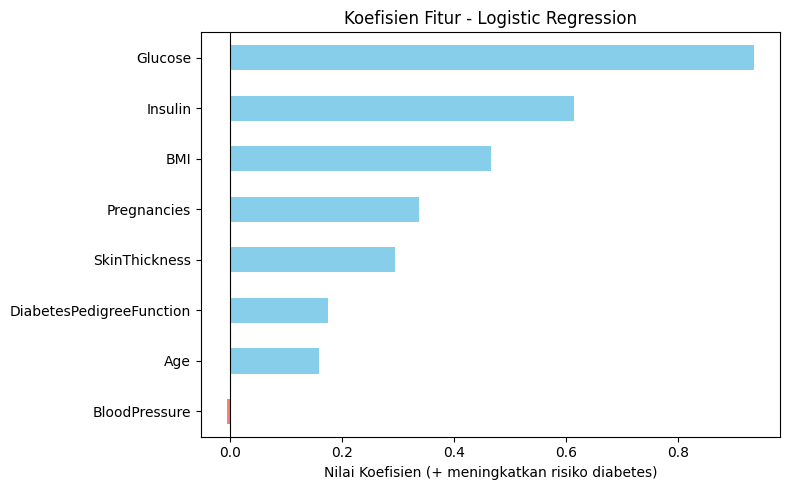

BloodPressure              -0.0042
Age                         0.1598
DiabetesPedigreeFunction    0.1747
SkinThickness               0.2950
Pregnancies                 0.3372
BMI                         0.4661
Insulin                     0.6142
Glucose                     0.9349
dtype: float64


In [18]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.

# Ambil koefisien LR
coef = pd.Series(lr_model.coef_[0], index=X_train.columns).sort_values()

plt.figure(figsize=(8, 5))
coef.plot(kind='barh', color=['salmon' if v < 0 else 'skyblue' for v in coef])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Koefisien Fitur - Logistic Regression')
plt.xlabel('Nilai Koefisien (+ meningkatkan risiko diabetes)')
plt.tight_layout()
plt.show()

print(coef.round(4))

# 5. Analisis

### dataset ini memiliki 768 data yang mana outcomes sebagai targetnya memiliki class yang imbalanced karena 65% dari data tersebut merupakan non diabetes sedangkan 35% nya itu merupakan diabetes. dari persebaran data yang ada pada dataset tersebut, dapat dilihat bahwa fitur Glucose/BP/Skin/Insulin/BMI tidak ada yang bernilai 0 sehingga tidak perlu untuk dilakukan imputasi. untuk model yang digunakan gaussian naive bbayes berkerja lebih baik karena data yang kecil dan untuk logistic regression sendiri modelnya sangat sensitif dengan jarak.

# 6. Kesimpulan dan Saran

### kedua model tersebut berhasil mendapatkan accuracy sebesar 0.71 sampai 0.73. tetapi dengan adanya imbalance class mengakibatkan hasil yang kurang maksimal. saran untuk eksperimen selanjutnya adalah mengatasi imbalance dataset dan menggunakan selection feature untuk mendapatkan hasil yang lebih maksimal